# Evaluation Figures

This notebook reproduces **aggregate reporting figures** (coverage and performance summaries) from the CSV tables included in this repository.

**Privacy note:** This public repository does **not** include protected clinical data such as raw audio, participant-level labels, annotation exports, or participant-level model scores. As a result, some figures (e.g., ROC curves) cannot be regenerated exactly from public files alone.


## Configuration

Optionally, if you have a locally available (protected) matched participant-level table, you can point to it here to recompute the aggregate metrics.
If you do **not** have protected data, leave `PROTECTED_MATCHED_TABLE = None` and the notebook will use the aggregate metrics CSV shipped with this repository.


In [1]:
from pathlib import Path

# -----------------------------------------------------------------------------
# Local configuration (optional)
# -----------------------------------------------------------------------------
# This notebook supports two modes:
# 1) Public aggregate mode (default): reproduces aggregate reporting figures from
#    results/final_matched_metrics_table.csv.
# 2) Protected local mode (optional): if you have controlled-access local outputs,
#    set RUN_PROTECTED_LOCAL = True and point to your local root/run folder.

RUN_PROTECTED_LOCAL: bool = False

# Root folder that may contain either:
# - vitogram_pcg/ project (with logs/, data/), or
# - parent folder that contains vitogram_pcg/ and Label/Annotation/.
PROTECTED_DATA_ROOT: Path | None = None

# Optional: explicit run folder (e.g., .../logs/rr_clean_10s_rf).
PROTECTED_RUN_DIR: Path | None = None
LEGACY_RUN_NAME: str = 'rr_clean_10s_rf'

# If True and local root/run is set, the notebook will auto-discover common
# local files (matched table, OOF predictions, labels, annotation exports).
AUTO_INFER_PROTECTED_PATHS: bool = True

# If True, protected-local mode is turned on automatically when discoverable
# local sources are found (useful for your local code_v04 setup).
AUTO_ENABLE_PROTECTED_LOCAL: bool = True

# Optional: participant ID and time window for methodology examples.
METHODOLOGY_EXAMPLE_PARTICIPANT: str | None = None
METHODOLOGY_TIME_WINDOW: tuple[float, float] | None = None

# Optional protected local inputs (leave as None in the public repository).
PROTECTED_MATCHED_TABLE: Path | None = None
PROTECTED_PCG_PREDICTIONS_CSV: Path | None = None
PROTECTED_LABELS_CSV: Path | None = None

PROTECTED_RAW_AUDIO_PATH: Path | None = None
PROTECTED_PREPROCESSED_AUDIO_PATH: Path | None = None
PROTECTED_ANNOTATION_CSV: Path | None = None
PROTECTED_ANNOTATION_KEY_CSV: Path | None = None

# Methodology exact-match behavior:
# - True: prefer exact legacy image files from code_v04 run_dir/methodology_figures.
# - False: regenerate with plotting functions from src/methodology_figures.py.
PREFER_LEGACY_METHODOLOGY_ASSETS: bool = True

# Export controls
SAVE_REGENERATED_FIGURES: bool = False
EXPORT_FIGURES_TO_REPOSITORY: bool = False
EXPORT_FIGURES_TO_RUN_DIR: bool = False
FIGURE_DPI: int = 300



In [3]:
from __future__ import annotations

import json
import os
import shutil
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure config variables exist even if config cells were not executed.
globals().setdefault('RUN_PROTECTED_LOCAL', False)
globals().setdefault('PROTECTED_DATA_ROOT', None)
globals().setdefault('PROTECTED_RUN_DIR', None)
globals().setdefault('LEGACY_RUN_NAME', 'rr_clean_10s_rf')
globals().setdefault('AUTO_INFER_PROTECTED_PATHS', True)
globals().setdefault('AUTO_ENABLE_PROTECTED_LOCAL', True)
globals().setdefault('METHODOLOGY_EXAMPLE_PARTICIPANT', None)
globals().setdefault('METHODOLOGY_TIME_WINDOW', None)
globals().setdefault('PROTECTED_MATCHED_TABLE', None)
globals().setdefault('PROTECTED_PCG_PREDICTIONS_CSV', None)
globals().setdefault('PROTECTED_LABELS_CSV', None)
globals().setdefault('PROTECTED_RAW_AUDIO_PATH', None)
globals().setdefault('PROTECTED_PREPROCESSED_AUDIO_PATH', None)
globals().setdefault('PROTECTED_ANNOTATION_CSV', None)
globals().setdefault('PROTECTED_ANNOTATION_KEY_CSV', None)
globals().setdefault('PREFER_LEGACY_METHODOLOGY_ASSETS', True)
globals().setdefault('SAVE_REGENERATED_FIGURES', False)
globals().setdefault('EXPORT_FIGURES_TO_REPOSITORY', False)
globals().setdefault('EXPORT_FIGURES_TO_RUN_DIR', False)
globals().setdefault('FIGURE_DPI', 300)

def find_repo_root() -> Path:
    """Locate the repository root in a notebook-friendly way."""

    def is_root(p: Path) -> bool:
        return (p / 'src' / 'evaluate_metrics.py').exists() and (p / 'results' / 'final_matched_metrics_table.csv').exists()

    candidates: list[Path] = [Path.cwd().resolve()]

    vsc = globals().get('__vsc_ipynb_file__')
    if vsc:
        try:
            candidates.append(Path(vsc).resolve().parent)
        except Exception:
            pass

    sess = os.environ.get('JPY_SESSION_NAME') or globals().get('__session__')
    if sess:
        try:
            candidates.append((Path.cwd() / Path(str(sess))).resolve().parent)
        except Exception:
            pass

    for start in candidates:
        probe = start
        while True:
            if is_root(probe):
                return probe
            if probe == probe.parent:
                break
            probe = probe.parent

    raise RuntimeError(
        'Could not locate repository root.'
        ' Tip: start Jupyter from the repository root, or set REPO_ROOT manually in this cell.'
    )

REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT))

from src.evaluate_metrics import (  # noqa: E402
    compute_method_metrics_table,
    confusion_matrix_from_metrics_row,
    validate_metric_table,
    compute_roc_curve,
)
from src.local_data_paths import discover_local_figure_sources  # noqa: E402


def _discover_sources() -> object | None:
    """Try a few common local roots and return discovered sources if found."""

    candidate_roots: list[Path] = []
    if PROTECTED_DATA_ROOT is not None:
        candidate_roots.append(Path(PROTECTED_DATA_ROOT).expanduser().resolve())

    candidate_roots.extend(
        [
            (REPO_ROOT.parent.parent / 'code_v04').resolve(),
            (REPO_ROOT.parent.parent / 'Code_v04').resolve(),
            (REPO_ROOT.parent / 'code_v04').resolve(),
        ]
    )

    seen: set[Path] = set()
    for root in candidate_roots:
        if root in seen:
            continue
        seen.add(root)
        try:
            d = discover_local_figure_sources(
                data_root=root,
                run_dir_hint=PROTECTED_RUN_DIR,
                run_name=LEGACY_RUN_NAME,
            )
        except Exception:
            continue

        if any([
            d.run_dir is not None,
            d.matched_table_csv is not None,
            d.pcg_predictions_csv is not None,
            d.labels_csv is not None,
        ]):
            return d

    if PROTECTED_RUN_DIR is not None:
        return discover_local_figure_sources(
            data_root=Path(PROTECTED_DATA_ROOT).expanduser().resolve() if PROTECTED_DATA_ROOT is not None else None,
            run_dir_hint=PROTECTED_RUN_DIR,
            run_name=LEGACY_RUN_NAME,
        )

    return None


discovered = _discover_sources() if AUTO_INFER_PROTECTED_PATHS else None

if (not RUN_PROTECTED_LOCAL) and AUTO_ENABLE_PROTECTED_LOCAL and discovered is not None:
    if any([
        discovered.run_dir is not None,
        discovered.matched_table_csv is not None,
        discovered.pcg_predictions_csv is not None,
    ]):
        RUN_PROTECTED_LOCAL = True
        print('Auto-enabled protected-local mode from discovered local paths.')

if RUN_PROTECTED_LOCAL and discovered is not None:
    PROTECTED_RUN_DIR = PROTECTED_RUN_DIR or discovered.run_dir
    PROTECTED_MATCHED_TABLE = PROTECTED_MATCHED_TABLE or discovered.matched_table_csv
    PROTECTED_PCG_PREDICTIONS_CSV = PROTECTED_PCG_PREDICTIONS_CSV or discovered.pcg_predictions_csv
    PROTECTED_LABELS_CSV = PROTECTED_LABELS_CSV or discovered.labels_csv

    if METHODOLOGY_EXAMPLE_PARTICIPANT:
        PROTECTED_ANNOTATION_CSV = PROTECTED_ANNOTATION_CSV or discovered.annotation_csv
        PROTECTED_ANNOTATION_KEY_CSV = PROTECTED_ANNOTATION_KEY_CSV or discovered.annotation_key_csv

        if discovered.raw_audio_root is not None and discovered.preprocessed_audio_root is not None:
            pid = str(METHODOLOGY_EXAMPLE_PARTICIPANT)
            raw_matches = sorted(discovered.raw_audio_root.glob(f'*{pid}*.wav'))
            pre_matches = sorted(discovered.preprocessed_audio_root.glob(f'{pid}_*.wav'))
            if raw_matches and PROTECTED_RAW_AUDIO_PATH is None:
                PROTECTED_RAW_AUDIO_PATH = raw_matches[0]
            if pre_matches and PROTECTED_PREPROCESSED_AUDIO_PATH is None:
                PROTECTED_PREPROCESSED_AUDIO_PATH = pre_matches[0]

AGGREGATE_METRICS_CSV = REPO_ROOT / 'results' / 'final_matched_metrics_table.csv'
REPO_MAIN_FIG_DIR = REPO_ROOT / 'figures' / 'main'
REPO_METHODOLOGY_FIG_DIR = REPO_ROOT / 'figures' / 'methodology'

RUN_DISSERTATION_FIG_DIR = None
RUN_METHODOLOGY_FIG_DIR = None
if PROTECTED_RUN_DIR is not None:
    RUN_DISSERTATION_FIG_DIR = Path(PROTECTED_RUN_DIR) / 'dissertation_figures'
    RUN_METHODOLOGY_FIG_DIR = Path(PROTECTED_RUN_DIR) / 'methodology_figures'

if SAVE_REGENERATED_FIGURES or EXPORT_FIGURES_TO_REPOSITORY:
    REPO_MAIN_FIG_DIR.mkdir(parents=True, exist_ok=True)
    REPO_METHODOLOGY_FIG_DIR.mkdir(parents=True, exist_ok=True)

if EXPORT_FIGURES_TO_RUN_DIR and RUN_DISSERTATION_FIG_DIR is not None:
    RUN_DISSERTATION_FIG_DIR.mkdir(parents=True, exist_ok=True)
if EXPORT_FIGURES_TO_RUN_DIR and RUN_METHODOLOGY_FIG_DIR is not None:
    RUN_METHODOLOGY_FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_figure_outputs(
    fig,
    *,
    repo_base_name: str | None,
    run_base_name: str | None,
    kind: str,
    save_repo: bool = False,
    save_run: bool = False,
    dpi: int = 300,
) -> list[Path]:
    """Save one figure to repo and/or local run folders (PNG + PDF)."""

    saved: list[Path] = []

    if save_repo and repo_base_name:
        target_dir = REPO_METHODOLOGY_FIG_DIR if kind == 'methodology' else REPO_MAIN_FIG_DIR
        for ext in ('png', 'pdf'):
            out = target_dir / f'{repo_base_name}.{ext}'
            try:
                fig.savefig(out, bbox_inches='tight', dpi=int(dpi))
                saved.append(out)
            except OSError as exc:
                print(f'Warning: could not save {out}: {exc}')

    if save_run and run_base_name:
        target_dir = RUN_METHODOLOGY_FIG_DIR if kind == 'methodology' else RUN_DISSERTATION_FIG_DIR
        if target_dir is not None:
            for ext in ('png', 'pdf'):
                out = target_dir / f'{run_base_name}.{ext}'
                try:
                    fig.savefig(out, bbox_inches='tight', dpi=int(dpi))
                    saved.append(out)
                except OSError as exc:
                    print(f'Warning: could not save {out}: {exc}')

    return saved


def copy_legacy_asset_outputs(
    *,
    src_png: Path,
    src_pdf: Path | None,
    repo_base_name: str | None,
    run_base_name: str | None,
    kind: str,
    copy_repo: bool = False,
    copy_run: bool = False,
) -> list[Path]:
    """Copy legacy methodology assets exactly as-is to export targets."""

    copied: list[Path] = []

    def _copy_pair(target_dir: Path, base_name: str) -> None:
        if src_png.exists():
            out_png = target_dir / f'{base_name}.png'
            try:
                shutil.copyfile(src_png, out_png)
                copied.append(out_png)
            except OSError as exc:
                print(f'Warning: could not copy {src_png} -> {out_png}: {exc}')
        if src_pdf is not None and src_pdf.exists():
            out_pdf = target_dir / f'{base_name}.pdf'
            try:
                shutil.copyfile(src_pdf, out_pdf)
                copied.append(out_pdf)
            except OSError as exc:
                print(f'Warning: could not copy {src_pdf} -> {out_pdf}: {exc}')

    if copy_repo and repo_base_name:
        target_dir = REPO_METHODOLOGY_FIG_DIR if kind == 'methodology' else REPO_MAIN_FIG_DIR
        _copy_pair(target_dir, repo_base_name)

    if copy_run and run_base_name:
        target_dir = RUN_METHODOLOGY_FIG_DIR if kind == 'methodology' else RUN_DISSERTATION_FIG_DIR
        if target_dir is not None:
            _copy_pair(target_dir, run_base_name)

    return copied


def pick_legacy_methodology_assets(run_dir: Path) -> dict[str, tuple[Path, Path | None]]:
    """Pick preferred legacy M1/M2 assets from run_dir/methodology_figures."""

    mdir = run_dir / 'methodology_figures'

    def _pick(bases: list[str]) -> tuple[Path, Path | None] | None:
        for base in bases:
            png = mdir / f'{base}.png'
            pdf = mdir / f'{base}.pdf'
            if png.exists():
                return png, (pdf if pdf.exists() else None)
        return None

    m1 = _pick([
        'figM1_preprocessing_example_final_v3',
        'figM1_preprocessing_example_final_clean',
        'figM1_preprocessing_example_final',
        'figM1_preprocessing_example_v3',
        'figM1_preprocessing_example',
    ])
    m2 = _pick([
        'figM2_s1s2_annotation_rr_example_final_preferred_v3',
        'figM2_s1s2_annotation_rr_example_final_preferred_v2',
        'figM2_s1s2_annotation_rr_example_final_preferred',
        'figM2_s1s2_annotation_rr_example_final_clean_v2',
        'figM2_s1s2_annotation_rr_example_final_clean',
        'figM2_s1s2_annotation_rr_example_final',
        'figM2_s1s2_annotation_rr_example_v3',
        'figM2_s1s2_annotation_rr_example',
    ])

    out: dict[str, tuple[Path, Path | None]] = {}
    if m1 is not None:
        out['M1'] = m1
    if m2 is not None:
        out['M2'] = m2
    return out


print('Mode:', 'protected-local' if RUN_PROTECTED_LOCAL else 'public aggregate')
if RUN_PROTECTED_LOCAL:
    print('PROTECTED_RUN_DIR =', PROTECTED_RUN_DIR)
    print('PROTECTED_MATCHED_TABLE =', PROTECTED_MATCHED_TABLE)
    print('PROTECTED_PCG_PREDICTIONS_CSV =', PROTECTED_PCG_PREDICTIONS_CSV)
    print('PROTECTED_LABELS_CSV =', PROTECTED_LABELS_CSV)
else:
    print('Protected-local mode is off. Set RUN_PROTECTED_LOCAL=True or AUTO_ENABLE_PROTECTED_LOCAL=True.')



Mode: protected-local
PROTECTED_RUN_DIR = /Users/soonheekim/Desktop/FYP/code_v04/vitogram_pcg/logs/rr_clean_10s_rf
PROTECTED_MATCHED_TABLE = /Users/soonheekim/Desktop/FYP/code_v04/vitogram_pcg/logs/rr_clean_10s_rf/dissertation_figures/final_matched_metrics_table.csv
PROTECTED_PCG_PREDICTIONS_CSV = /Users/soonheekim/Desktop/FYP/code_v04/vitogram_pcg/logs/rr_clean_10s_rf/af_rr/oof_predictions.csv
PROTECTED_LABELS_CSV = /Users/soonheekim/Desktop/FYP/code_v04/Label/Annotation/device_labels_4class.csv


## Load metrics

- If a protected matched table is provided, recompute metrics using reusable functions from `src/evaluate_metrics.py`.
- Otherwise, load and validate the included aggregate metrics table.


In [4]:
if PROTECTED_MATCHED_TABLE is not None and PROTECTED_MATCHED_TABLE.exists():
    matched = pd.read_csv(PROTECTED_MATCHED_TABLE)

    # Expected columns in a matched table.
    methods = [
        {'method': 'PCG', 'pred_col': 'pcg_pred_4class', 'prob_col': 'pcg_paf'},
        {'method': 'FibriCheck iOS', 'pred_col': 'fibricheck_ios_4class'},
        {'method': 'FibriCheck Android', 'pred_col': 'fibricheck_android_4class'},
        {'method': 'Kardia', 'pred_col': 'kardia_4class'},
    ]

    if all(m['pred_col'] in matched.columns for m in methods) and 'ecg12_4class' in matched.columns:
        df_metrics = compute_method_metrics_table(matched, methods=methods)
    else:
        # Fall back to reading pre-aggregated metrics directly.
        df_metrics = pd.read_csv(PROTECTED_MATCHED_TABLE)
else:
    df_metrics = pd.read_csv(AGGREGATE_METRICS_CSV)

df_metrics = validate_metric_table(df_metrics)
df_metrics



,method,n_ref,n_classified_AF_SR,n_OA,n_UI,n_missing,classified_rate,OA_rate,UI_rate,missing_rate,sensitivity,specificity,accuracy,PPV,NPV,F1,AUC
0,PCG,67,26,0,41,0,0.388060,0.000000,0.611940,0.000000,0.875,0.888889,0.884615,0.777778,0.941176,0.823529,0.944444
1,FibriCheck iOS,67,61,4,2,0,0.910448,0.059701,0.029851,0.000000,1.000,0.977778,0.983607,0.941176,1.000000,0.969697,NaN
2,FibriCheck Android,67,38,2,27,0,0.567164,0.029851,0.402985,0.000000,1.000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN
3,Kardia,67,57,7,1,2,0.850746,0.104478,0.014925,0.029851,1.000,0.977273,0.982456,0.928571,1.000000,0.962963,NaN


## Figure 2: Coverage and AF/SR-classified performance

This figure is regenerated from the metrics table (protected-mode recomputation or public aggregate CSV).
The x-axis labels intentionally do not include sample-size text.


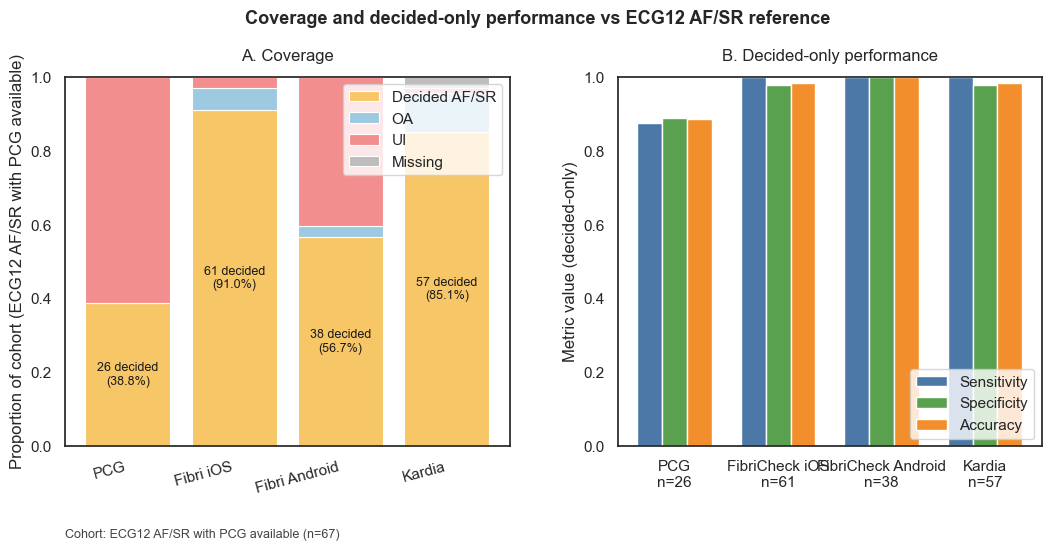

Saved Figure 2 outputs:
- /Users/soonheekim/Desktop/FYP/github_push/Code_v01/figures/main/fig2_coverage_performance.png
- /Users/soonheekim/Desktop/FYP/github_push/Code_v01/figures/main/fig2_coverage_performance.pdf


In [5]:
# Figure 2: use the dissertation-style layout to avoid text/grid overlap.
order = ['PCG', 'FibriCheck iOS', 'FibriCheck Android', 'Kardia']
labels = {
    'PCG': 'PCG',
    'FibriCheck iOS': 'FibriCheck iOS',
    'FibriCheck Android': 'FibriCheck Android',
    'Kardia': 'Kardia',
}

df2 = df_metrics.set_index('method').loc[order].reset_index()
n_ref = int(df2['n_ref'].iloc[0])

x = np.arange(len(order))
classified_n = df2['n_classified_AF_SR'].astype(int).to_numpy()
oa_n = df2['n_OA'].astype(int).to_numpy()
ui_n = df2['n_UI'].astype(int).to_numpy()
missing_n = df2['n_missing'].astype(int).to_numpy()

decided = classified_n / n_ref
oa = oa_n / n_ref
ui = ui_n / n_ref
missing = missing_n / n_ref

sens = df2['sensitivity'].astype(float).to_numpy()
spec = df2['specificity'].astype(float).to_numpy()
acc = df2['accuracy'].astype(float).to_numpy()

sns.set_theme(style='white')
fig = plt.figure(figsize=(12.6, 5.6))
gs = fig.add_gridspec(1, 2, width_ratios=[1.05, 1.0], wspace=0.25)

# Panel A
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(x, decided, label='Decided AF/SR', color='#f6c667', edgecolor='white', linewidth=0.8)
ax1.bar(x, oa, bottom=decided, label='OA', color='#9ecae1', edgecolor='white', linewidth=0.8)
ax1.bar(x, ui, bottom=decided + oa, label='UI', color='#f28e8e', edgecolor='white', linewidth=0.8)
if np.any(missing > 0):
    ax1.bar(x, missing, bottom=decided + oa + ui, label='Missing', color='#bdbdbd', edgecolor='white', linewidth=0.8)

ax1.set_ylim(0, 1.0)
ax1.set_xticks(x)
ax1.set_xticklabels([name.replace('FibriCheck', 'Fibri') for name in order], rotation=15, ha='right')
ax1.set_ylabel('Proportion of cohort (ECG12 AF/SR with PCG available)')
ax1.set_title('A. Coverage', pad=12)
ax1.legend(loc='upper right', frameon=True)
ax1.grid(False)

for xi, n in zip(x, classified_n):
    pct = (n / n_ref) * 100.0
    y = max(0.03, (n / n_ref) / 2.0)
    ax1.text(xi, y, f'{n} decided\n({pct:.1f}%)', ha='center', va='center', fontsize=9, color='#1a1a1a')

ax1.text(0.0, -0.22, f'Cohort: ECG12 AF/SR with PCG available (n={n_ref})', transform=ax1.transAxes, ha='left', va='top', fontsize=9, color='#444444')

# Panel B
ax2 = fig.add_subplot(gs[0, 1])
width = 0.24
ax2.bar(x - width, sens, width, label='Sensitivity', color='#4c78a8')
ax2.bar(x, spec, width, label='Specificity', color='#59a14f')
ax2.bar(x + width, acc, width, label='Accuracy', color='#f28e2b')

ax2.set_ylim(0, 1.0)
ax2.set_xticks(x)
ax2.set_xticklabels([f"{labels[m]}\nn={int(df2.loc[df2['method'] == m, 'n_classified_AF_SR'].iloc[0])}" for m in order], rotation=0, ha='center')
ax2.set_ylabel('Metric value (decided-only)')
ax2.set_title('B. Decided-only performance', pad=12)
ax2.legend(loc='lower right', frameon=True)
ax2.grid(False)

fig.suptitle('Coverage and decided-only performance vs ECG12 AF/SR reference', y=0.98, fontsize=13, fontweight='bold')
fig.subplots_adjust(top=0.86, bottom=0.20)

plt.show()

saved = save_figure_outputs(
    fig,
    repo_base_name='fig2_coverage_performance',
    run_base_name='fig2_coverage_performance_notebook',
    kind='main',
    save_repo=bool(SAVE_REGENERATED_FIGURES or EXPORT_FIGURES_TO_REPOSITORY),
    save_run=bool(EXPORT_FIGURES_TO_RUN_DIR),
    dpi=int(FIGURE_DPI),
)
if saved:
    print('Saved Figure 2 outputs:')
    for path in saved:
        print('-', path)

plt.close(fig)



## Figure 3: PCG confusion matrix (aggregate)

The public repository includes enough aggregate counts (`tp/fp/tn/fn`) to reproduce the **PCG confusion matrix**.

**ROC note:** The ROC curve shown in the tracked Figure 3 was generated from participant-level probability scores (`pAF`), which are not included in this public repository. Therefore, this notebook does not attempt to reproduce the ROC curve from aggregate outputs.

If you provide a local protected matched table that contains participant-level PCG probability scores (e.g., `pcg_paf`), the notebook can additionally display the ROC curve and AUC in protected-local mode.


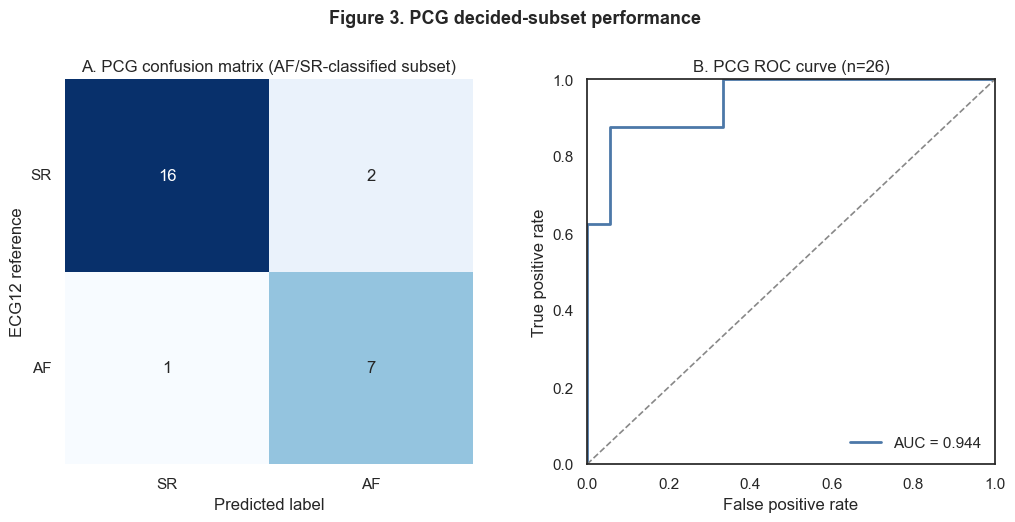

Saved Figure 3 outputs:
- /Users/soonheekim/Desktop/FYP/github_push/Code_v01/figures/main/fig3_pcg_performance.png
- /Users/soonheekim/Desktop/FYP/github_push/Code_v01/figures/main/fig3_pcg_performance.pdf


In [6]:
# Build confusion matrix and ROC source from local/public tables.
cm = None
pcg_row = df_metrics[df_metrics['method'] == 'PCG'].iloc[0]

try:
    cm = confusion_matrix_from_metrics_row(pcg_row)
except ValueError:
    summary_pcg = None
    if PROTECTED_RUN_DIR is not None:
        candidate = Path(PROTECTED_RUN_DIR) / 'evaluation' / 'summary_PCG.json'
        if candidate.exists():
            summary_pcg = json.loads(candidate.read_text(encoding='utf-8'))
    if isinstance(summary_pcg, dict):
        metrics = summary_pcg.get('metrics') or {}
        needed = ['tp', 'fp', 'tn', 'fn']
        if all(k in metrics for k in needed):
            tp = int(metrics['tp'])
            fp = int(metrics['fp'])
            tn = int(metrics['tn'])
            fn = int(metrics['fn'])
            cm = np.asarray([[tn, fp], [fn, tp]], dtype=int)

if cm is None:
    raise ValueError(
        'Cannot build PCG confusion matrix from current metrics table. '
        'Provide tp/fp/tn/fn columns or a local run with evaluation/summary_PCG.json.'
    )

roc_df = None
roc_source = None

if PROTECTED_MATCHED_TABLE is not None and PROTECTED_MATCHED_TABLE.exists():
    cand = pd.read_csv(PROTECTED_MATCHED_TABLE)
    if 'ecg12_4class' in cand.columns:
        roc_df = cand
        roc_source = str(PROTECTED_MATCHED_TABLE)

if roc_df is None and PROTECTED_PCG_PREDICTIONS_CSV is not None and PROTECTED_PCG_PREDICTIONS_CSV.exists():
    pred = pd.read_csv(PROTECTED_PCG_PREDICTIONS_CSV)
    if PROTECTED_LABELS_CSV is not None and PROTECTED_LABELS_CSV.exists() and 'participant_id' in pred.columns:
        lab = pd.read_csv(PROTECTED_LABELS_CSV, usecols=['participant_id', 'ecg12_4class'])
        lab['participant_id'] = lab['participant_id'].astype(str)
        pred['participant_id'] = pred['participant_id'].astype(str)
        roc_df = pred.merge(lab, on='participant_id', how='left')
        roc_source = f"{PROTECTED_PCG_PREDICTIONS_CSV} + {PROTECTED_LABELS_CSV}"

roc_ready = False
fpr = tpr = None
auc = float('nan')
n_roc = 0
if roc_df is not None:
    if 'pcg_paf' in roc_df.columns:
        prob_col = 'pcg_paf'
    elif 'pcg_paf_oof' in roc_df.columns:
        prob_col = 'pcg_paf_oof'
    elif 'pcg_paf_full' in roc_df.columns:
        prob_col = 'pcg_paf_full'
    else:
        prob_col = None

    pred_candidates = ['pcg_pred_4class', 'pcg_pred_4class_oof', 'pcg_pred_oof', 'pcg_pred_full']
    pred_col = next((c for c in pred_candidates if c in roc_df.columns), None)

    if prob_col is not None and 'ecg12_4class' in roc_df.columns:
        sub = roc_df.copy()
        sub = sub[sub['ecg12_4class'].isin(['AF', 'SR'])]
        if pred_col is not None:
            sub = sub[sub[pred_col].isin(['AF', 'SR'])]
        p = pd.to_numeric(sub[prob_col], errors='coerce')
        sub = sub[np.isfinite(p.to_numpy())].copy()

        if len(sub) >= 3 and len(set(sub['ecg12_4class'].tolist())) == 2:
            y_true = (sub['ecg12_4class'].astype(str).str.upper() == 'AF').astype(int).to_numpy()
            y_score = pd.to_numeric(sub[prob_col], errors='coerce').to_numpy(dtype=float)
            fpr, tpr, _thr, auc = compute_roc_curve(y_true, y_score)
            n_roc = len(sub)
            roc_ready = True

# Plot Figure 3 (confusion + ROC when available).
if roc_ready:
    fig = plt.figure(figsize=(12.0, 5.0))
    gs = fig.add_gridspec(1, 2, wspace=0.28)

    ax1 = fig.add_subplot(gs[0, 0])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=0.0, ax=ax1)
    ax1.set_xlabel('Predicted label')
    ax1.set_ylabel('ECG12 reference')
    ax1.set_xticklabels(['SR', 'AF'])
    ax1.set_yticklabels(['SR', 'AF'], rotation=0)
    ax1.set_title('A. PCG confusion matrix (AF/SR-classified subset)')

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(fpr, tpr, lw=2.0, color='#4c78a8', label=f'AUC = {auc:.3f}')
    ax2.plot([0, 1], [0, 1], ls='--', lw=1.2, color='#888888')
    ax2.set_xlabel('False positive rate')
    ax2.set_ylabel('True positive rate')
    ax2.set_title(f'B. PCG ROC curve (n={n_roc})')
    ax2.legend(loc='lower right', frameon=False)
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)

    fig.suptitle('Figure 3. PCG decided-subset performance', y=1.02, fontsize=13, fontweight='bold')
else:
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=0.0, ax=ax)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('ECG12 reference')
    ax.set_xticklabels(['SR', 'AF'])
    ax.set_yticklabels(['SR', 'AF'], rotation=0)
    ax.set_title('PCG confusion matrix (AF/SR-classified subset)')

    if not RUN_PROTECTED_LOCAL:
        print('ROC skipped: protected-local mode is off.')
    elif roc_source is not None:
        print('ROC skipped: insufficient AF/SR probability rows in', roc_source)
    else:
        print('ROC skipped: no protected probability table configured.')

plt.show()

saved = save_figure_outputs(
    fig,
    repo_base_name='fig3_pcg_performance',
    run_base_name='fig3_pcg_confusion_roc_notebook',
    kind='main',
    save_repo=bool(SAVE_REGENERATED_FIGURES or EXPORT_FIGURES_TO_REPOSITORY),
    save_run=bool(EXPORT_FIGURES_TO_RUN_DIR),
    dpi=int(FIGURE_DPI),
)
if saved:
    print('Saved Figure 3 outputs:')
    for path in saved:
        print('-', path)

plt.close(fig)



## Methodology figures

To run it locally, set the `PROTECTED_*` paths and methodology parameters in the configuration cell above.

The plots below are **signal-derived** and should be displayed in the notebook only. Do not save or commit them.


Using exact legacy methodology assets from code_v04 run dir:
- /Users/soonheekim/Desktop/FYP/code_v04/vitogram_pcg/logs/rr_clean_10s_rf/methodology_figures/figM1_preprocessing_example_final_v3.png
- /Users/soonheekim/Desktop/FYP/code_v04/vitogram_pcg/logs/rr_clean_10s_rf/methodology_figures/figM2_s1s2_annotation_rr_example_final_preferred_v3.png


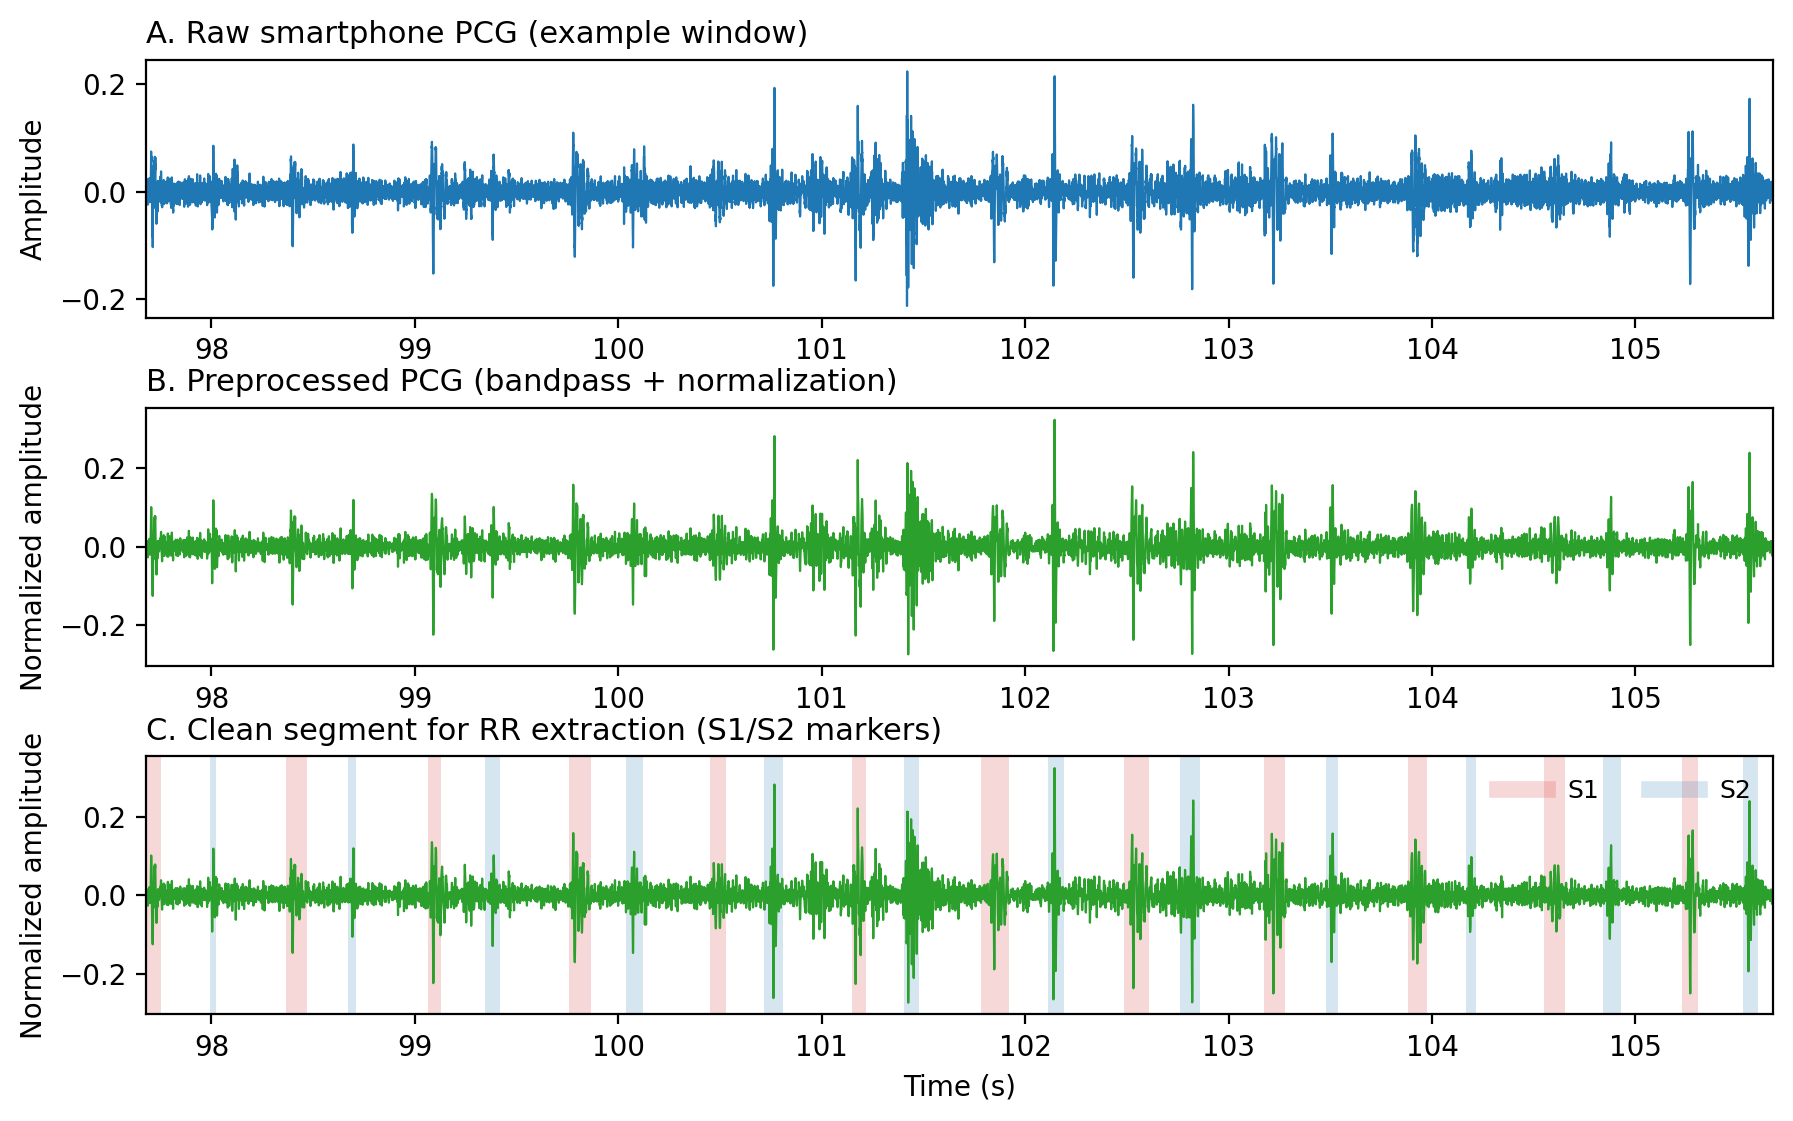

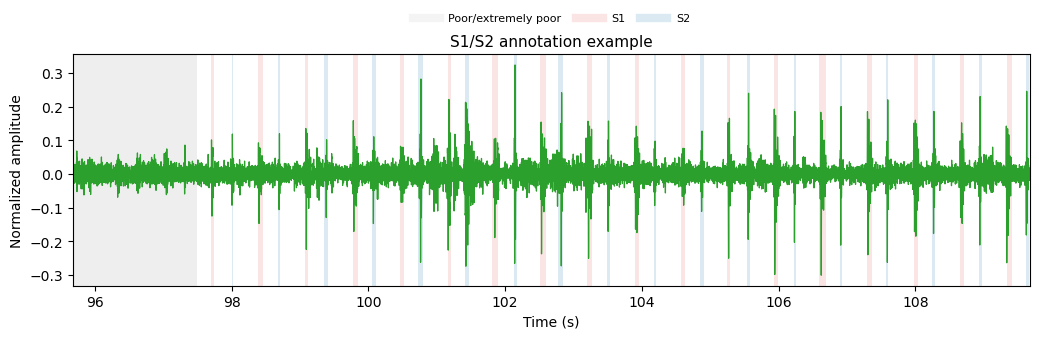

Copied methodology outputs:
- /Users/soonheekim/Desktop/FYP/github_push/Code_v01/figures/methodology/figM1_preprocessing_example.png
- /Users/soonheekim/Desktop/FYP/github_push/Code_v01/figures/methodology/figM1_preprocessing_example.pdf
- /Users/soonheekim/Desktop/FYP/github_push/Code_v01/figures/methodology/figM2_s1s2_annotation_rr_example.png
- /Users/soonheekim/Desktop/FYP/github_push/Code_v01/figures/methodology/figM2_s1s2_annotation_rr_example.pdf


In [7]:
# Optional protected-local methodology figures.
# This block is skipped unless RUN_PROTECTED_LOCAL = True and required local paths are set.

required = {
    'PROTECTED_RAW_AUDIO_PATH': PROTECTED_RAW_AUDIO_PATH,
    'PROTECTED_PREPROCESSED_AUDIO_PATH': PROTECTED_PREPROCESSED_AUDIO_PATH,
    'PROTECTED_ANNOTATION_CSV': PROTECTED_ANNOTATION_CSV,
    'PROTECTED_ANNOTATION_KEY_CSV': PROTECTED_ANNOTATION_KEY_CSV,
    'METHODOLOGY_EXAMPLE_PARTICIPANT': METHODOLOGY_EXAMPLE_PARTICIPANT,
    'METHODOLOGY_TIME_WINDOW': METHODOLOGY_TIME_WINDOW,
}

missing = [k for k, v in required.items() if v in (None, '')]

if RUN_PROTECTED_LOCAL and not missing:
    from IPython.display import Image, display

    legacy_used = False
    if PREFER_LEGACY_METHODOLOGY_ASSETS and PROTECTED_RUN_DIR is not None:
        assets = pick_legacy_methodology_assets(Path(PROTECTED_RUN_DIR))
        if 'M1' in assets and 'M2' in assets:
            legacy_used = True
            m1_png, m1_pdf = assets['M1']
            m2_png, m2_pdf = assets['M2']

            print('Using exact legacy methodology assets from code_v04 run dir:')
            print('-', m1_png)
            print('-', m2_png)

            display(Image(filename=str(m1_png)))
            display(Image(filename=str(m2_png)))

            copied_m1 = copy_legacy_asset_outputs(
                src_png=m1_png,
                src_pdf=m1_pdf,
                repo_base_name='figM1_preprocessing_example',
                run_base_name='figM1_preprocessing_example',
                kind='methodology',
                copy_repo=bool(EXPORT_FIGURES_TO_REPOSITORY),
                copy_run=bool(EXPORT_FIGURES_TO_RUN_DIR),
            )
            copied_m2 = copy_legacy_asset_outputs(
                src_png=m2_png,
                src_pdf=m2_pdf,
                repo_base_name='figM2_s1s2_annotation_rr_example',
                run_base_name='figM2_s1s2_annotation_rr_example',
                kind='methodology',
                copy_repo=bool(EXPORT_FIGURES_TO_REPOSITORY),
                copy_run=bool(EXPORT_FIGURES_TO_RUN_DIR),
            )
            copied = copied_m1 + copied_m2
            if copied:
                print('Copied methodology outputs:')
                for path in copied:
                    print('-', path)

    if not legacy_used:
        from src.methodology_figures import (
            load_annotation_payload_for_participant,
            plot_preprocessing_example,
            plot_s1s2_annotation_example,
        )

        start_s, duration_s = METHODOLOGY_TIME_WINDOW
        recording_filename = Path(PROTECTED_PREPROCESSED_AUDIO_PATH).name

        payload = load_annotation_payload_for_participant(
            PROTECTED_ANNOTATION_CSV,
            PROTECTED_ANNOTATION_KEY_CSV,
            participant_id=METHODOLOGY_EXAMPLE_PARTICIPANT,
            filename=recording_filename,
        )

        fig_m1 = plot_preprocessing_example(
            raw_wav=PROTECTED_RAW_AUDIO_PATH,
            preprocessed_wav=PROTECTED_PREPROCESSED_AUDIO_PATH,
            start_s=float(start_s),
            duration_s=float(duration_s),
            payload=payload,
        )
        display(fig_m1)

        saved_m1 = save_figure_outputs(
            fig_m1,
            repo_base_name='figM1_preprocessing_example',
            run_base_name='figM1_preprocessing_example',
            kind='methodology',
            save_repo=bool(EXPORT_FIGURES_TO_REPOSITORY),
            save_run=bool(EXPORT_FIGURES_TO_RUN_DIR),
            dpi=int(FIGURE_DPI),
        )
        if saved_m1:
            print('Saved M1 outputs:')
            for path in saved_m1:
                print('-', path)
        plt.close(fig_m1)

        fig_m2 = plot_s1s2_annotation_example(
            preprocessed_wav=PROTECTED_PREPROCESSED_AUDIO_PATH,
            payload=payload,
            start_s=float(start_s),
            duration_s=float(duration_s),
        )
        display(fig_m2)

        saved_m2 = save_figure_outputs(
            fig_m2,
            repo_base_name='figM2_s1s2_annotation_rr_example',
            run_base_name='figM2_s1s2_annotation_rr_example',
            kind='methodology',
            save_repo=bool(EXPORT_FIGURES_TO_REPOSITORY),
            save_run=bool(EXPORT_FIGURES_TO_RUN_DIR),
            dpi=int(FIGURE_DPI),
        )
        if saved_m2:
            print('Saved M2 outputs:')
            for path in saved_m2:
                print('-', path)
        plt.close(fig_m2)

elif RUN_PROTECTED_LOCAL:
    print('Protected local methodology config is incomplete; skipping signal-derived methodology figures.')
    print('Missing:', ', '.join(missing))
    print('Resolved values:')
    for k, v in required.items():
        print(f'  - {k}: {v}')
    print('Tip: set PROTECTED_DATA_ROOT/PROTECTED_RUN_DIR and METHODOLOGY_EXAMPLE_PARTICIPANT + METHODOLOGY_TIME_WINDOW.')

else:
    print('Protected-local mode is off; methodology figures are skipped.')

